In [1]:
import pandas as pd

df = pd.read_csv("data/anomaly_results.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,service,level,message,latency_ms,request_count,status_code,true_anomaly,error_flag,latency_roll_mean,latency_roll_std,req_roll_mean,req_roll_std,error_rate,anomaly_score,anomaly_flag
0,2026-04-02 19:16:22.428265,inventory-service,INFO,request processed successfully,124.47,19,200,0,0,0.0,0.0,0.0,0.0,0.0,0.055809,0
1,2026-04-02 19:16:23.428265,auth-service,INFO,user login successful,112.18,17,200,0,0,0.0,0.0,0.0,0.0,0.0,0.043652,0
2,2026-04-02 19:16:24.428265,auth-service,INFO,order created successfully,121.33,21,200,0,0,0.0,0.0,0.0,0.0,0.0,0.049152,0
3,2026-04-02 19:16:25.428265,inventory-service,INFO,api call completed,180.01,27,200,0,0,0.0,0.0,0.0,0.0,0.0,0.032131,0
4,2026-04-02 19:16:26.428265,payment-service,INFO,cache hit for request,124.18,11,200,0,0,0.0,0.0,0.0,0.0,0.0,0.021685,0


In [2]:
print("Total logs:", len(df))
print("True anomalies:", df["true_anomaly"].sum())
print("Detected anomalies:", df["anomaly_flag"].sum())

Total logs: 5000
True anomalies: 173
Detected anomalies: 150


In [3]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(df["true_anomaly"], df["anomaly_flag"]))
print(classification_report(df["true_anomaly"], df["anomaly_flag"]))

[[4790   37]
 [  60  113]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4827
           1       0.75      0.65      0.70       173

    accuracy                           0.98      5000
   macro avg       0.87      0.82      0.84      5000
weighted avg       0.98      0.98      0.98      5000



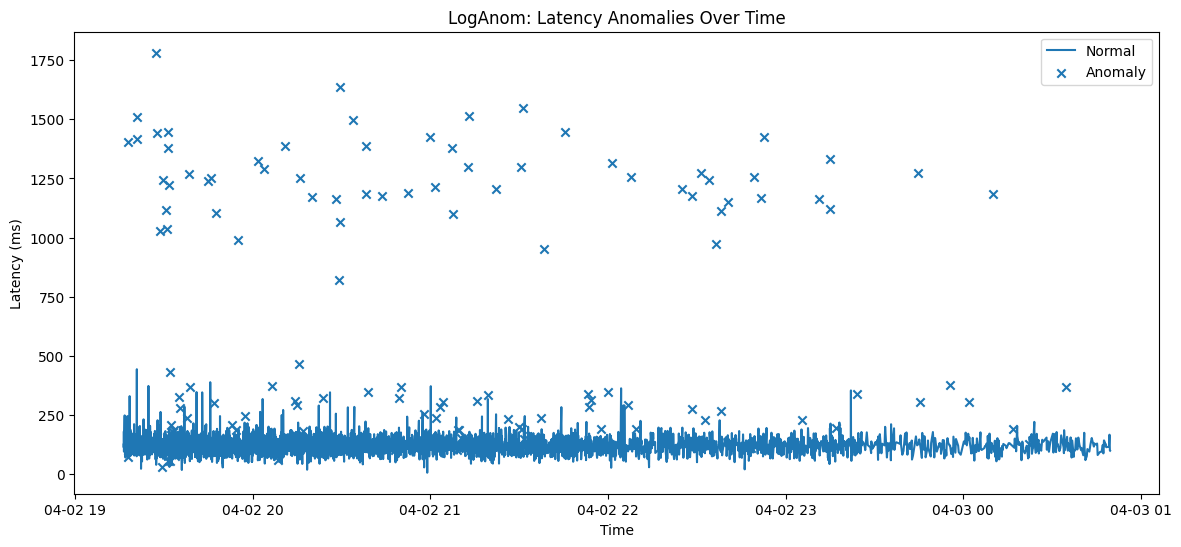

In [4]:
import matplotlib.pyplot as plt

normal = df[df["anomaly_flag"]==0]
anomaly = df[df["anomaly_flag"]==1]

plt.figure(figsize=(14,6))
plt.plot(normal["timestamp"], normal["latency_ms"], label="Normal")
plt.scatter(anomaly["timestamp"], anomaly["latency_ms"], marker="x", label="Anomaly")
plt.title("LogAnom: Latency Anomalies Over Time")
plt.xlabel("Time")
plt.ylabel("Latency (ms)")
plt.legend()
plt.show()

In [5]:
df[df["anomaly_flag"]==1]["service"].value_counts()

service
auth-service         50
search-service       29
payment-service      28
order-service        23
inventory-service    20
Name: count, dtype: int64